In [17]:
import pandas as pd
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [11]:
data = {
    "Review": [
        "The food was delicious and arrived on time.",
        "Delivery was very late and food was cold.",
        "Excellent packaging and tasty food.",
        "The price is too high for the quantity provided.",
        "Customer service was unhelpful and rude."
    ]
}

df = pd.DataFrame(data)
print(df.head())

                                             Review
0       The food was delicious and arrived on time.
1         Delivery was very late and food was cold.
2               Excellent packaging and tasty food.
3  The price is too high for the quantity provided.
4          Customer service was unhelpful and rude.


In [12]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['Processed_Review'] = df['Review'].apply(preprocess)

print(df[['Review','Processed_Review']])

                                             Review  \
0       The food was delicious and arrived on time.   
1         Delivery was very late and food was cold.   
2               Excellent packaging and tasty food.   
3  The price is too high for the quantity provided.   
4          Customer service was unhelpful and rude.   

                  Processed_Review  
0      food delicious arrived time  
1          delivery late food cold  
2   excellent packaging tasty food  
3     price high quantity provided  
4  customer service unhelpful rude  


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [13]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment'] = df['Review'].apply(get_sentiment)

print(df[['Review','Sentiment']])

                                             Review Sentiment
0       The food was delicious and arrived on time.  Positive
1         Delivery was very late and food was cold.  Negative
2               Excellent packaging and tasty food.  Positive
3  The price is too high for the quantity provided.  Positive
4          Customer service was unhelpful and rude.  Negative


In [14]:
all_words = " ".join(df['Processed_Review']).split()

word_freq = Counter(all_words)

print(word_freq.most_common(10))

[('food', 3), ('delicious', 1), ('arrived', 1), ('time', 1), ('delivery', 1), ('late', 1), ('cold', 1), ('excellent', 1), ('packaging', 1), ('tasty', 1)]


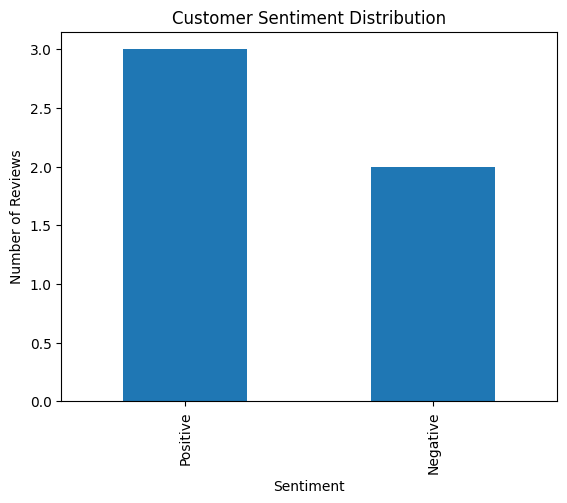

In [15]:
df['Sentiment'].value_counts().plot(kind='bar')

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

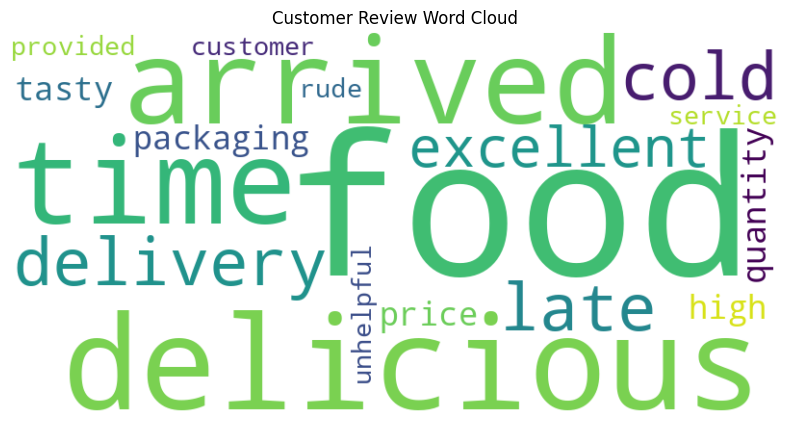

In [18]:
all_words = " ".join(df['Processed_Review'].astype(str))

wordcloud = WordCloud(width=800,height=400,background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Customer Review Word Cloud")
plt.show()